In [ ]:
!pip install yfinance

### Objective:
# Extract real data from yahoo finance
# Create a Predictive model using Deep learning MLP to predict the closing price
# Save the model for real time use

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score

In [ ]:
#create a function
def stock_data_extraction(ticker):
  try:
    data = yf.download(ticker, period ='2y',interval='1d')
    # print('Raw Stock Data - ')
    # print(data.head())
    return data
  except Exception as e:
    print("Issue in stock_data_extraction function \n",e)
    return None

In [ ]:
def data_prep(data):
  try:
    data.columns = data.columns.droplevel(1) #check with data.columns getting multilevel indexes which includes AAPL
    data.reset_index(inplace=True)
    final_df = data[['Close', 'High', 'Low', 'Open', 'Volume']]
    return final_df
  except Exception as e:
    print("Error in data_prep function\n",e)

In [ ]:
### Scaling the values
def feature_transformation(data):
  global scaler
  scaler = MinMaxScaler()
  scaled = scaler.fit_transform(data)
  return scaled

In [ ]:
data = stock_data_extraction("AAPL") ## Give the ticker you want to see stock prices for
final_df = data_prep(data)
scaled_df = feature_transformation(final_df)
# final_df
# scaled_df

/tmp/ipykernel_1399/1509174173.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period ='2y',interval='1d')
[*********************100%***********************]  1 of 1 completed


In [ ]:
### creating x and y
x = []
y = []

for i in range(len(scaled_df) - 1):
  x.append(scaled_df[i])
  y.append(scaled_df[i+1][0])

x = np.array(x)
y = np.array(y)

In [ ]:
close_index = final_df.columns.get_loc('Close')
close_index

0

In [ ]:
x = scaled_df[:-1]
y = scaled_df[1:,close_index]

In [ ]:
split = int(len(x) * 0.8) #80% of the data taken for training
x_train = x[:split]
y_train = y[:split]
x_test = x[split:]
y_test = y[split:]

In [ ]:
##Build the neural network
model = Sequential() ##creating layer by layer or create at the time of creation
model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'RMSprop',loss='mse') #can use adam too

model.fit(x_train,y_train,epochs=50,verbose=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1892
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0440 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0013
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012
Epoch 14/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014
Epoch 15/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012
Epoch 1

In [ ]:
predict = model.predict(x_test)
r2_score(y_test,predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


0.7648130693759245

In [ ]:
##Convert back to real prices
#need to create a dummy array
dummy = np.zeros((len(predict),5))
dummy[:,close_index] = predict.flatten()

In [ ]:
global scaler
predicted_close = scaler.inverse_transform(dummy)[:,close_index]
predicted_close

array([251.7336751 , 250.33166641, 249.44993788, 251.66605356,
       249.88132068, 253.16612371, 263.25275746, 264.76800378,
       261.43880314, 261.08379736, 263.56902751, 268.67709485,
       270.3022663 , 270.91524518, 273.37407753, 275.10737193,
       270.53735839, 270.95895694, 270.75063474, 271.31769839,
       270.61190406, 271.29117656, 274.49611496, 275.22068251,
       275.23643509, 273.76069791, 269.65059546, 269.79595113,
       269.65211308, 270.6399654 , 271.50623319, 275.95136431,
       278.17907372, 278.28881644, 277.94333226, 281.46434371,
       285.8563801 , 285.77362616, 282.39527077, 280.44438794,
       278.71754341, 278.49607339, 278.8296866 , 278.20082381,
       278.91428648, 277.47720477, 274.88887148, 274.80459263,
       273.11265331, 276.97331195, 273.01346094, 272.36403006,
       273.7453977 , 274.26418943, 273.90833   , 273.56627504,
       273.22254195, 273.43099548, 270.1913051 , 266.43912693,
       263.67860241, 260.3996072 , 260.85441092, 261.68

In [ ]:
dummy[:,close_index] = y_test
actual_close = scaler.inverse_transform(dummy)[:,close_index]

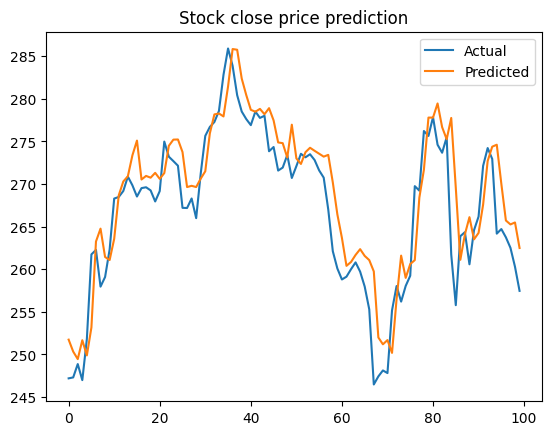

In [ ]:
import matplotlib.pyplot as plt
plt.plot(actual_close, label = 'Actual')
plt.plot(predicted_close, label = 'Predicted')
plt.legend()
plt.title('Stock close price prediction')
plt.show()